# CS 614 - Applications of Machine Learning 
## Programming Assignment 3 - Transfer Learning for Image Classification

**Train on GPU:** Upload to [Google Colab](https://colab.research.google.com) → *Runtime → Change runtime type → GPU* → Run All. (No local setup.)

### Introduction
We're going to load a ResNet18 model trained using the IMAGENET 1K dataset, and then modify and fine-tune it to work on the CIFAR10 dataset.

### Download, Import, and Transform the Data
First lets load our data.   We'll download it directy from Pytorch.  We'll reshape each image to $224\times 224$ and standardize it using a previuosly known mean and standard deviation.

In [3]:
import torchvision
import torchvision.transforms as transforms
import torch
from torch import nn

batch_size = 128
#Loading the dataset and preprocessing
train_dataset = torchvision.datasets.CIFAR10(root = './data', train = True,
                                               transform = transforms.Compose([
                                                    transforms.Resize((224,224)),
                                                    transforms.RandomHorizontalFlip(p=0.5),
                                                    transforms.ToTensor(),
                                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
                                               download = True)
    
test_dataset = torchvision.datasets.CIFAR10(root = './data', train = False,
                                               transform = transforms.Compose([
                                                    transforms.Resize((224,224)),
                                                    transforms.ToTensor(),
                                                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
                                               download = True)


# AMD GPU (ROCm 5.7): 1) Add user to render: sudo usermod -aG render $USER, then log out/in. 2) pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm5.7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# num_workers=0 avoids multiprocessing issues in Jupyter; pin_memory helps CPU->GPU transfer
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=(device.type == 'cuda'))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=(device.type == 'cuda'))

Files already downloaded and verified
Files already downloaded and verified


In [4]:
print(device)

cuda


### CIFAR10 Dataset Description (for report)
The following cell prints dataset statistics and shows one example image from each of the 10 classes.

Training set size: 50000
Test set size: 10000
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image shape (after transform): 3 x 224 x 224 (C x H x W)
Class priors: 1/10 per class (5000 training and 1000 test images per class)


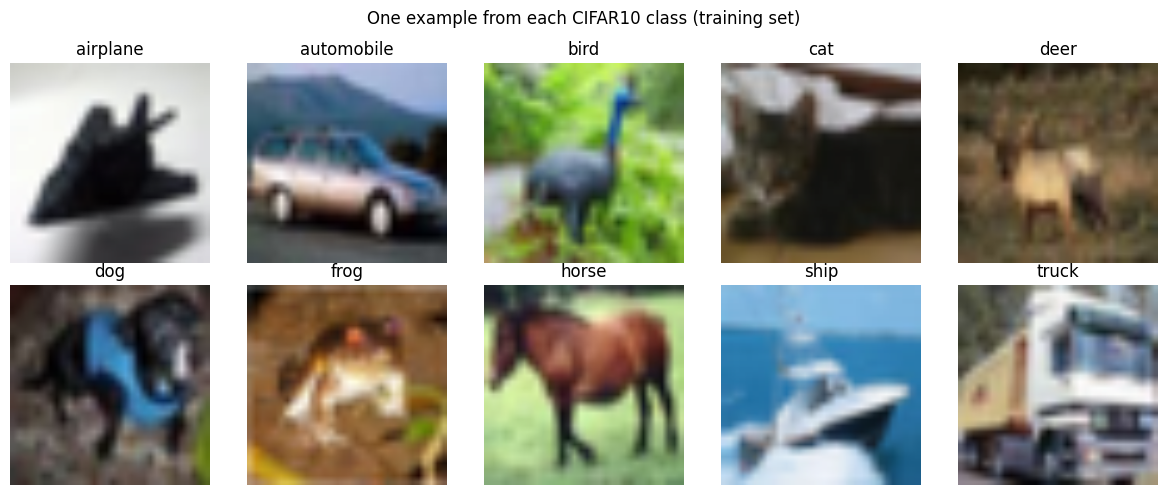

In [5]:
# CIFAR10: number of observations and features
import matplotlib.pyplot as plt
import numpy as np
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print('Training set size:', len(train_dataset))
print('Test set size:', len(test_dataset))
print('Number of classes:', 10)
print('Class names:', CIFAR10_CLASSES)
print('Image shape (after transform): 3 x 224 x 224 (C x H x W)')
# Class priors: CIFAR10 is balanced (5000 train, 1000 test per class)
print('Class priors: 1/10 per class (5000 training and 1000 test images per class)')
# One example per class (from training set)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
found = {c: None for c in range(10)}
for idx in range(len(train_dataset)):
    _, label = train_dataset[idx]
    if found[label] is None:
        found[label] = idx
    if all(v is not None for v in found.values()):
        break
for c in range(10):
    img, _ = train_dataset[found[c]]
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    ax = axes[c // 5, c % 5]
    ax.imshow(img_np)
    ax.set_title(CIFAR10_CLASSES[c])
    ax.axis('off')
plt.suptitle('One example from each CIFAR10 class (training set)', fontsize=12)
plt.tight_layout()
plt.show()

### Load Pre-Trained Model
Next let's load a ResNet18 model pretrained using the ImageNet1K dataset

In [6]:
#get model trained with Imagenet1k
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
print(model)  # Non-augmented ResNet18 architecture (before replacing fc)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Freeze the Existing Network
When we fine-tune our model, we don't want to backpropagate the layers related to the pre-trained ResNet model

In [7]:
#don't backprop old architecture
for param in model.parameters():
    param.requires_grad = False

### Alter the Last Fully Connected Layer for our New Dataset
We will need to change the last layer (model.fc) to be a linear layer that takes us down to 10 classes (required for CIFAR10 dataset)

In [8]:
num_ftrs = model.fc.in_features  #number of features in to last fully-connected layer
model.fc = nn.Linear(num_ftrs,10) #change it!
# Unfreeze last ResNet block (layer4) for fine-tuning; use smaller LR to avoid forgetting
for param in model.layer4.parameters():
    param.requires_grad = True


### Objective and Optimizer
The next thing we need for our model is an objective function and optimizer.  Make your choices!

In [9]:
# Loss: Cross-Entropy for multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Optimizer: fc with lr=1e-3, layer4 with lr=1e-4 (smaller LR for unfrozen backbone)
optimizer = torch.optim.Adam([
    {'params': model.fc.parameters(), 'lr': 1e-3},
    {'params': model.layer4.parameters(), 'lr': 1e-4}
])

# Move model to GPU so training runs on GPU
model = model.to(device)
print(device)


cuda


### Fine-Tune Model using CIFAR10 Training Set
Now fine-tune your model using the CIFAR10 dataset.
Again, keep track of the training loss to plot, then report final training and testing accuracies.

In [10]:
# Train augmented ResNet model with CIFAR10 training dataset.
# Keep track of loss each epoch. Adapts to model device (GPU/CPU).
import time
num_epochs = 10
losses = []
epoch_losses = []
NUM_BATCHES = None  # set to None to train on full dataset; set to int to limit batches per epoch (e.g. for debugging)
model.train()
device = next(model.parameters()).device
start_time = time.time()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    n_batches = 0
    for i, (images, labels) in enumerate(train_loader):
        if NUM_BATCHES is not None and i >= NUM_BATCHES:
            break
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        #Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        epoch_loss += loss.item()
        n_batches += 1
    epoch_loss /= max(n_batches, 1)
    epoch_losses.append(epoch_loss)
    print('Epoch [{}/{}], Mean Loss: {:.4f}'.format(epoch+1, num_epochs, epoch_loss))
training_time = time.time() - start_time
print('Total training time: {:.2f} s ({:.2f} min)'.format(training_time, training_time/60))


MIOpen(HIP): Warning [FindSolutionImpl] Invalid config loaded from Perf Db: ConvBinWinogradRxSf3x2: 39. Performance may degrade.


Epoch [1/10], Mean Loss: 0.4386
Epoch [2/10], Mean Loss: 0.1987
Epoch [3/10], Mean Loss: 0.1164
Epoch [4/10], Mean Loss: 0.0737
Epoch [5/10], Mean Loss: 0.0470
Epoch [6/10], Mean Loss: 0.0341
Epoch [7/10], Mean Loss: 0.0270
Epoch [8/10], Mean Loss: 0.0234
Epoch [9/10], Mean Loss: 0.0183
Epoch [10/10], Mean Loss: 0.0177
Total training time: 754.83 s (12.58 min)


### Report Statistics and Provide Examples
Finally, provide your training plot, training and testing accuracies and examples of success and failure cases.

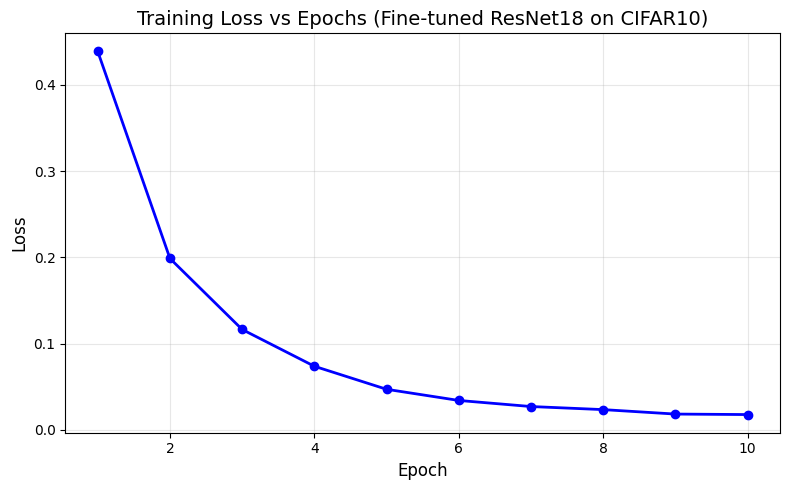

In [11]:
# Plot loss vs epochs (mean loss per epoch)
import matplotlib.pyplot as plt
if not epoch_losses or len(epoch_losses) == 0:
    print("No training loss data to plot (run the training cell first or kernel was restarted).")
else:
    n = len(epoch_losses)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, n + 1), epoch_losses, 'b-o', linewidth=2, markersize=6)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss vs Epochs (Fine-tuned ResNet18 on CIFAR10)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [21]:
# Compute training and testing accuracy
def evaluate(model, loader, device=None):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            if device is not None:
                images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return 100.0 * correct / total, np.array(all_preds), np.array(all_labels)

import numpy as np
device = next(model.parameters()).device
train_acc, train_preds, train_labels = evaluate(model, train_loader, device)
test_acc, test_preds, test_labels = evaluate(model, test_loader, device)
print('Training Accuracy: {:.2f}%'.format(train_acc))
print('Testing Accuracy:  {:.2f}%'.format(test_acc))

Training Accuracy: 99.47%
Testing Accuracy:  90.74%


In [24]:
import matplotlib.pyplot as plt
# Confusion matrices (training and testing)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# If kernel was restarted, recompute predictions (requires model, train_loader, test_loader from above)
if 'train_labels' not in dir() or 'train_preds' not in dir():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # free fragmented GPU memory before full train pass
    def _evaluate(model, loader, device=None):
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in loader:
                if device is not None:
                    images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        return np.array(all_preds), np.array(all_labels)
    device = next(model.parameters()).device
    train_preds, train_labels = _evaluate(model, train_loader, device)
    test_preds, test_labels = _evaluate(model, test_loader, device)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cm_train = confusion_matrix(train_labels, train_preds)
cm_test = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm_train, xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Training Set)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(cm_test, xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix (Testing Set)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
fig.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print('Saved: confusion_matrices.png')

Saved: confusion_matrices.png


In [25]:
# Success and failure examples (on test set)
import matplotlib.pyplot as plt
if 'CIFAR10_CLASSES' not in dir():
    CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
import numpy as np
model.eval()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
# Get one success and one failure per class (or global best/worst)
test_images_list, test_labels_list, preds_list = [], [], []
device = next(model.parameters()).device
with torch.no_grad():
    for images, labels in test_loader:
        test_images_list.append(images)
        test_labels_list.append(labels)
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        _, preds = torch.max(outputs, 1)
        preds_list.append(preds.cpu())
test_images_all = torch.cat(test_images_list, dim=0)
test_labels_all = torch.cat(test_labels_list, dim=0)
preds_all = torch.cat(preds_list, dim=0)

# One success example: correct prediction
success_idx = (preds_all == test_labels_all).nonzero(as_tuple=True)[0]
if len(success_idx) > 0:
    idx = success_idx[0].item()
    img = test_images_all[idx].cpu()
    img_show = img.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    plt.figure(figsize=(3, 3))
    plt.imshow(img_show)
    plt.title('Success: True={}, Pred={}'.format(CIFAR10_CLASSES[test_labels_all[idx].item()], CIFAR10_CLASSES[preds_all[idx].item()]))
    plt.axis('off')
    plt.savefig('success_example.png', dpi=150, bbox_inches='tight')
    plt.close()
    print('Saved: success_example.png')

# One failure example: wrong prediction
fail_idx = (preds_all != test_labels_all).nonzero(as_tuple=True)[0]
if len(fail_idx) > 0:
    idx = fail_idx[0].item()
    img = test_images_all[idx].cpu()
    img_show = img.permute(1, 2, 0).numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)
    plt.figure(figsize=(3, 3))
    plt.imshow(img_show)
    plt.title('Failure: True={}, Pred={}'.format(CIFAR10_CLASSES[test_labels_all[idx].item()], CIFAR10_CLASSES[preds_all[idx].item()]))
    plt.axis('off')
    plt.savefig('failure_example.png', dpi=150, bbox_inches='tight')
    plt.close()
    print('Saved: failure_example.png')

Saved: success_example.png
Saved: failure_example.png
